In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#import the words
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# building the dataset

block_size = 3
X, Y = [], []

for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
C = torch.randn((27, 2))

In [7]:
emb = C[X]

In [8]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [9]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [10]:
h

tensor([[ 0.9104, -0.9902,  0.9996,  ..., -1.0000, -0.9999, -0.6691],
        [ 0.8894, -0.9859,  0.9978,  ..., -1.0000, -1.0000, -0.2717],
        [ 0.9993, -0.9996,  0.9345,  ..., -1.0000, -0.9615,  0.8879],
        ...,
        [-0.8848,  0.3178, -0.9260,  ..., -0.6360, -0.8065,  0.9694],
        [-0.9760,  0.9104, -0.3866,  ..., -0.9780,  0.9971,  0.9882],
        [-0.9841, -0.2459, -0.9881,  ..., -0.9925, -0.8667,  0.6818]])

In [11]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [12]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [13]:
logits

tensor([[ 12.4996,  -2.0874,  10.8096,  ..., -12.3532,   7.4017, -14.0960],
        [ 12.4523,  -3.2232,   9.7469,  ...,  -9.9555,   7.2496, -16.3307],
        [  3.1866,  -3.7853,  16.1867,  ...,  -2.4572,   3.7050,   2.2191],
        ...,
        [ -1.7402,  -7.3472,  -2.8458,  ...,  15.2020, -17.4934,  -4.8851],
        [ -0.2341,  -4.3870,  -0.4365,  ...,   2.9828, -14.9467,   5.2482],
        [  6.8194,   7.0522,   3.8762,  ...,   5.3557, -11.4449,   7.7720]])

In [14]:
counts = logits.exp()

In [15]:
prob = counts / counts.sum(1, keepdim=True)

In [16]:
prob.shape

torch.Size([228146, 27])

In [17]:
loss = -prob[torch.arange(Y.shape[0]), Y].log().mean()
loss

tensor(18.3842)

In [18]:
# Rewriting for better understanding

In [19]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [20]:
sum(p.nelement() for p in parameters)

3481

In [21]:
for p in parameters:
    p.requires_grad = True

In [22]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [23]:
lri = []
lossi = []
for i in range(10000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 +b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())


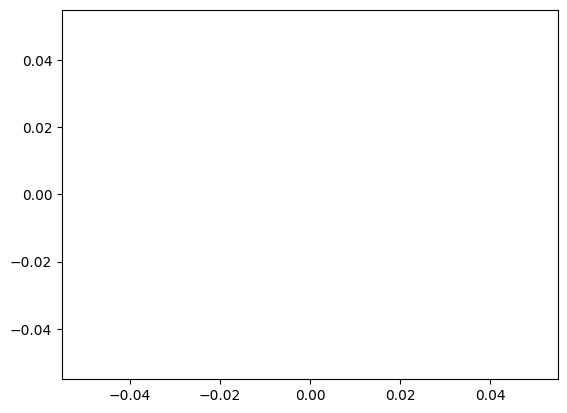

In [24]:
plt.plot(lri, lossi)

In [25]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 +b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.5720, grad_fn=<NllLossBackward0>)

In [26]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_tr, Y_tr = build_dataset(words[:n1])
X_dev, Y_dev = build_dataset(words[n1:n2])
X_te, Y_te = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [27]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [28]:
sum(p.nelement() for p in parameters)

11897

In [29]:
for p in parameters:
    p.requires_grad = True

In [30]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [31]:
lri = []
lossi = []
stepi = []

In [32]:
for i in range(50000):

    # minibatch construct
    ix = torch.randint(0, X_tr.shape[0], (32,))

    # forward pass
    emb = C[X_tr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 +b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y_tr[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

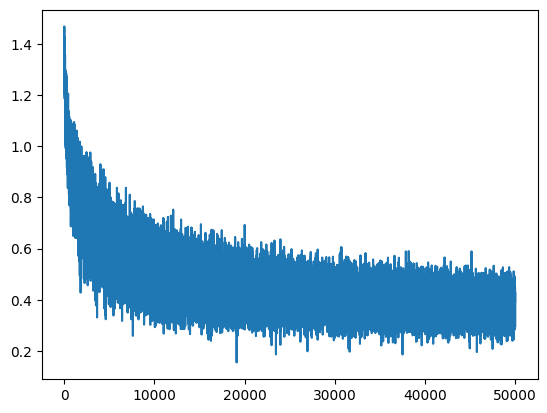

In [33]:
plt.plot(stepi, lossi)

In [34]:
emb = C[X_tr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 +b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y_tr)
loss

tensor(2.4080, grad_fn=<NllLossBackward0>)

In [35]:
emb = C[X_dev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 +b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y_dev)
loss

tensor(2.4143, grad_fn=<NllLossBackward0>)

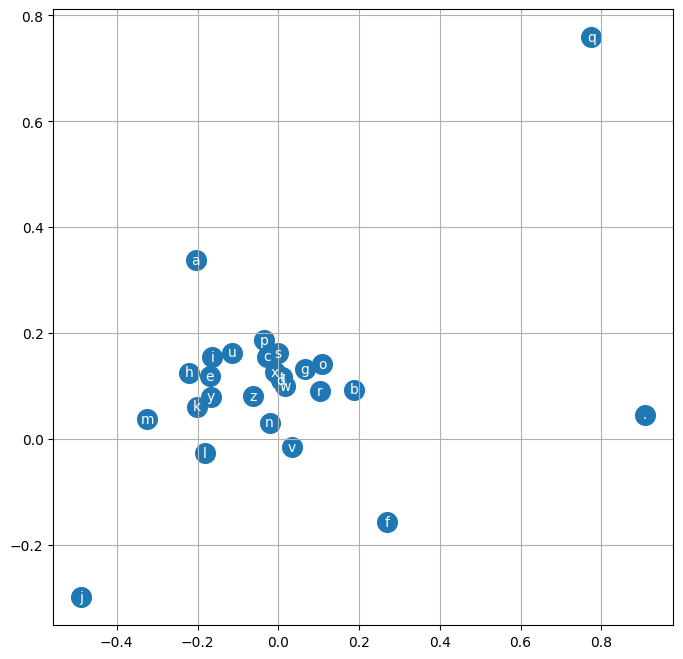

In [36]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

In [37]:
# sample from the model
g = torch.Generator().manual_seed(2147483547 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

jah.
amritlii.
sobryylin.
annidten.
lhni.
muil.
jaxoniy.
ada.
kin.
rahrettineshan.
luw.
avet.
lul.
hra.
delyy.
kalakiferd.
ana.
jaizeklajyosavyhanneka.
anna.
zamilclun.
